# Week 3 Day 3 — Optimization: SGD, Momentum, Adam
**Jul 15, 2026**

Every notebook so far has used `Adam` without asking why. Today: compare it against plain `SGD` and `SGD` with momentum on the same problem, then a learning-rate experiment that overturns the usual "Adam is just more robust" assumption.

Scaffold as usual: TODO stubs, hints not formulas, self-check cells.

## Part 1: Setup

Given. A `make_model` factory (so every run starts from *identical* weights — `torch.manual_seed` fixed inside it — making the comparison fair) and a `train` helper that takes an optimizer constructor and returns the loss curve.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
n_samples, n_features = 200, 10
X = torch.randn(n_samples, n_features)
true_w = torch.randn(n_features)
y = (X @ true_w > 0).float()
criterion = nn.BCEWithLogitsLoss()

def make_model():
    torch.manual_seed(1)
    return nn.Sequential(nn.Linear(n_features, 32), nn.ReLU(), nn.Linear(32, 1))

def train(optimizer_fn, n_epochs=100):
    model = make_model()
    optimizer = optimizer_fn(model.parameters())
    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        loss = criterion(model(X).squeeze(-1), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

## Part 2: Three optimizers, same learning rate

TODO: run `train` three times with `lr=0.5` (deliberately on the large side, to make differences visible fast): plain `torch.optim.SGD`, `SGD` with `momentum=0.9`, and `Adam`.

Conceptually, what momentum adds over plain SGD: instead of stepping purely by the current gradient, it keeps a running "velocity" — an exponential moving average of past gradients — and steps by that instead. Gradients that consistently point the same direction across steps build up speed; directions that flip back and forth cancel out and get damped. That's the entire mechanism; no formula needed to use `momentum=0.9`, just the argument.

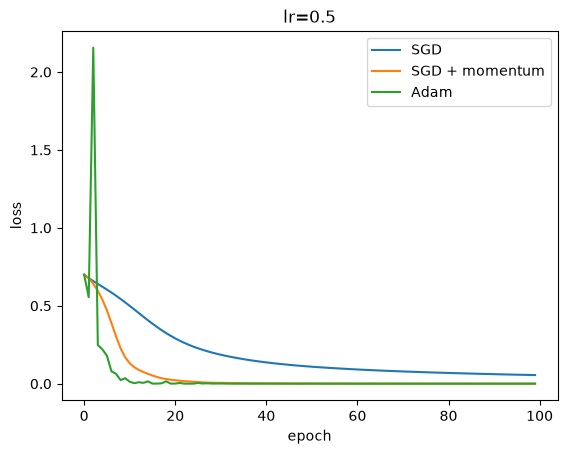

SGD             epoch 10: 0.4993   epoch 99: 0.0554
SGD+momentum    epoch 10: 0.1313   epoch 99: 0.0008
Adam            epoch 10: 0.0126   epoch 99: 0.0000


In [2]:
lr = 0.5

# TODO: sgd_losses = train(lambda params: torch.optim.SGD(params, lr=lr))
sgd_losses = train(lambda params: torch.optim.SGD(params, lr=lr))

# TODO: momentum_losses = train(lambda params: torch.optim.SGD(params, lr=lr, momentum=...))
momentum_losses = train(lambda params: torch.optim.SGD(params, lr=lr, momentum=0.9))
# TODO: adam_losses = train(lambda params: torch.optim.Adam(params, lr=lr))
adam_losses = train(lambda params: torch.optim.Adam(params, lr=lr))

plt.plot(sgd_losses, label="SGD")
plt.plot(momentum_losses, label="SGD + momentum")
plt.plot(adam_losses, label="Adam")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title(f"lr={lr}")
plt.show()

for name, losses in [("SGD", sgd_losses), ("SGD+momentum", momentum_losses), ("Adam", adam_losses)]:
    print(f"{name:15s} epoch 10: {losses[10]:.4f}   epoch 99: {losses[99]:.4f}")

Expect a clear ordering in convergence speed at this learning rate: plain `SGD` slowest, momentum noticeably faster, `Adam` fastest of the three by a wide margin.

## Part 3: The same learning rate is not "the same" across optimizers

TODO: rerun plain `SGD` and `Adam` (skip momentum here) at `lr=5.0` — 10x larger — and compare.

Before running it: don't assume Adam will just be "more robust" the way Part 2 might suggest. Adam divides its update by a running estimate of each parameter's gradient magnitude — this normalization means Adam's update size is only loosely coupled to the raw learning rate you set, in a way that's fundamentally different from SGD's, where the update scales directly with the raw gradient. That difference in mechanism means a learning rate that's merely aggressive for SGD can be catastrophic for Adam, or vice versa depending on the problem — the two optimizers don't share a common notion of what a "reasonable" learning rate value is. Run it and see which one actually holds up at `lr=5.0`.

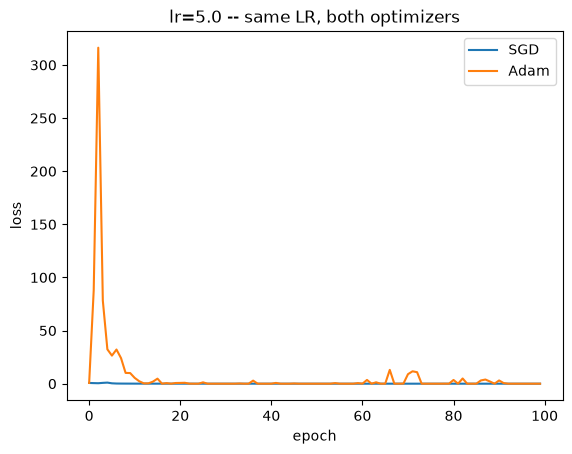

max loss reached -- SGD: 1.0221714973449707  Adam: 316.2748718261719


In [3]:
big_lr = 5.0

# TODO: sgd_big = train(lambda params: torch.optim.SGD(params, lr=big_lr))
sgd_big = train(lambda params: torch.optim.SGD(params, lr=big_lr))
# TODO: adam_big = train(lambda params: torch.optim.Adam(params, lr=big_lr))
adam_big = train(lambda params: torch.optim.Adam(params, lr=big_lr))


plt.plot(sgd_big, label="SGD")
plt.plot(adam_big, label="Adam")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title(f"lr={big_lr} -- same LR, both optimizers")
plt.show()

print("max loss reached -- SGD:", max(sgd_big), " Adam:", max(adam_big))

If this matches what usually happens here, `Adam`'s loss will spike into a completely different numerical range than `SGD`'s at this same nominal `lr` -- worth sitting with, since "just use Adam, it's more forgiving" is a common assumption this directly contradicts. The practical takeaway: a learning rate is only meaningful *relative to the optimizer it's paired with*. Adam's usual default (`lr=1e-3`, which every earlier notebook in this curriculum used without discussion) exists because Adam's update mechanics call for a much smaller nominal value than SGD typically does -- it's a different scale, not a more forgiving one.

## Try yourself

1. Find, by trial and error, an `lr` where plain `SGD` still converges reasonably but `Adam` has already started to blow up. How far apart are the two optimizers' "reasonable" ranges here?
2. Try `lr=0.001` (tiny) for plain `SGD` on this problem and watch how many epochs it takes to move at all. Then try the same tiny `lr` for `Adam` -- does it suffer the same way?
3. Add `torch.optim.RMSprop` as a fourth comparison in Part 2 -- where does it land relative to the other three?
4. Look up `torch.optim.lr_scheduler.StepLR` (or any scheduler) and use it to decay `lr` partway through one of these training runs -- does starting at a large LR and decaying it recover some of Adam's stability at `lr=5.0`?